# Learned Model Comparison Graphs

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set the plot style.
sns.set_theme(style="whitegrid", context="paper")

# Find the project root.
PROJECT_ROOT = Path.cwd().resolve()

if not (PROJECT_ROOT / "runs").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

# Training history files.
YOLO_HISTORY = (
    PROJECT_ROOT
    / "runs"
    / "yolo"
    / "yolo26n_blocks"
    / "results.csv"
)

FRCNN_HISTORY = (
    PROJECT_ROOT
    / "runs"
    / "faster_rcnn"
    / "faster_rcnn_training_history.csv"
)

if not YOLO_HISTORY.exists():
    raise FileNotFoundError(YOLO_HISTORY)

if not FRCNN_HISTORY.exists():
    raise FileNotFoundError(FRCNN_HISTORY)

## Load Results

In [2]:
# Load both training histories.
yolo = pd.read_csv(YOLO_HISTORY)
frcnn = pd.read_csv(FRCNN_HISTORY)

# Clean column names.
yolo.columns = yolo.columns.str.strip()
frcnn.columns = frcnn.columns.str.strip()

yolo_epoch = yolo["epoch"].astype(int)

# Use one-based epoch numbering.
if yolo_epoch.min() == 0:
    yolo_epoch = yolo_epoch + 1

# Combine validation mAP for both models.
validation = pd.concat(
    [
        pd.DataFrame({
            "Epoch": yolo_epoch,
            "Model": "YOLO26n",
            "mAP@0.50:0.95": yolo["metrics/mAP50-95(B)"],
        }),
        pd.DataFrame({
            "Epoch": frcnn["epoch"].astype(int),
            "Model": "Faster R-CNN",
            "mAP@0.50:0.95": frcnn["val_map50_95"],
        }),
    ],
    ignore_index=True,
)

## Validation mAP@0.50:0.95

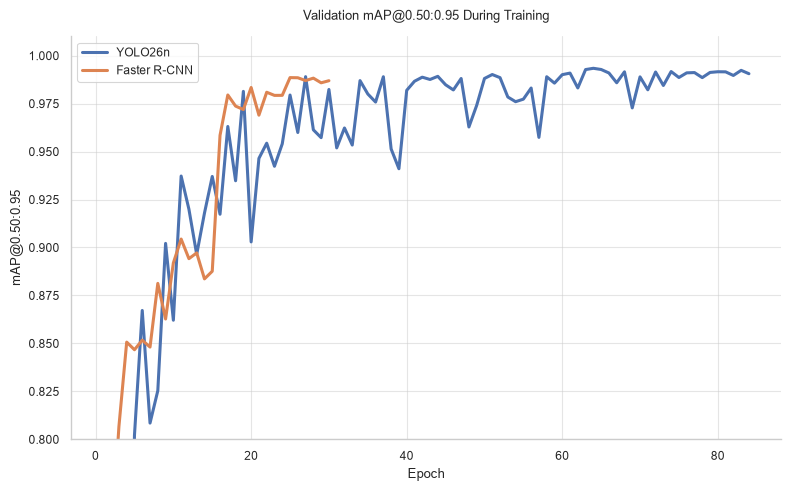

In [3]:
# Plot validation performance over training.
fig, ax = plt.subplots(figsize=(8, 5))

sns.lineplot(
    data=validation,
    x="Epoch",
    y="mAP@0.50:0.95",
    hue="Model",
    linewidth=2.2,
    ax=ax,
)

ax.set_title(
    "Validation mAP@0.50:0.95 During Training",
    pad=12,
)
ax.set_xlabel("Epoch")
ax.set_ylabel("mAP@0.50:0.95")
ax.set_ylim(0.80, 1.01)
ax.legend(title="")

sns.despine()
plt.tight_layout()
plt.show()

## Training Loss

YOLO records its loss components separately. The Faster R-CNN history stores total training loss.

### YOLO26n Loss Components

YOLO loss columns: ['train/box_loss', 'train/cls_loss', 'train/l1_loss']


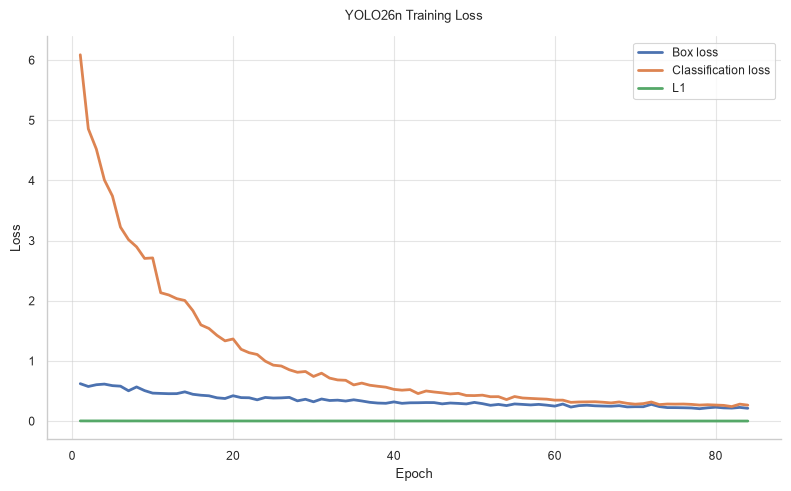

In [4]:
# Find the YOLO loss columns saved during training.
yolo_loss_columns = [
    column
    for column in yolo.columns
    if column.startswith("train/")
    and column.endswith("_loss")
]

if not yolo_loss_columns:
    raise ValueError(
        "No YOLO training-loss columns were found in results.csv"
    )

loss_names = {
    "train/box_loss": "Box loss",
    "train/cls_loss": "Classification loss",
    "train/dfl_loss": "DFL loss",
    "train/obj_loss": "Objectness loss",
}

# Reshape the loss data for plotting.
yolo_losses = yolo[
    ["epoch"] + yolo_loss_columns
].copy()

if yolo_losses["epoch"].min() == 0:
    yolo_losses["epoch"] += 1

yolo_losses = yolo_losses.melt(
    id_vars="epoch",
    var_name="Loss",
    value_name="Value",
)

yolo_losses["Loss"] = yolo_losses["Loss"].map(
    lambda name: loss_names.get(
        name,
        name.replace("train/", "")
            .replace("_loss", "")
            .replace("_", " ")
            .title(),
    )
)

print("YOLO loss columns:", yolo_loss_columns)

# Plot the recorded YOLO loss components.
fig, ax = plt.subplots(figsize=(8, 5))

sns.lineplot(
    data=yolo_losses,
    x="epoch",
    y="Value",
    hue="Loss",
    linewidth=2,
    ax=ax,
)

ax.set_title("YOLO26n Training Loss", pad=12)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend(title="")

sns.despine()
plt.tight_layout()
plt.show()

### Faster R-CNN Total Training Loss

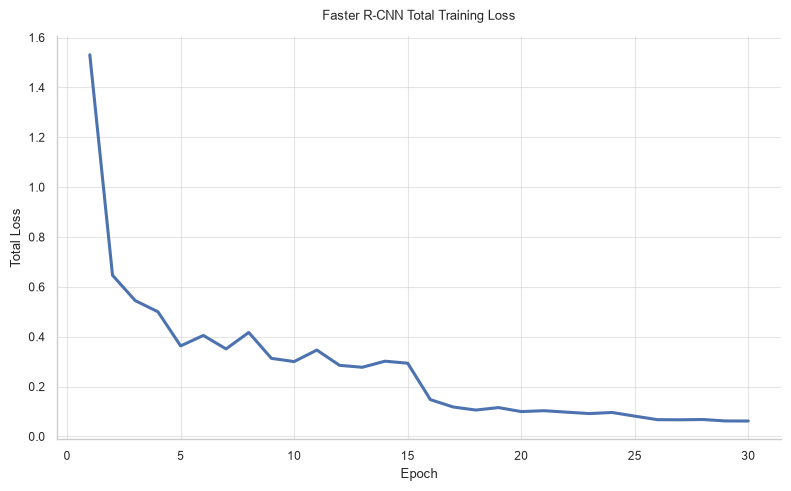

In [5]:
# Plot the saved total Faster R-CNN training loss.
fig, ax = plt.subplots(figsize=(8, 5))

sns.lineplot(
    data=frcnn,
    x="epoch",
    y="train_loss",
    linewidth=2.2,
    ax=ax,
)

ax.set_title("Faster R-CNN Total Training Loss", pad=12)
ax.set_xlabel("Epoch")
ax.set_ylabel("Total Loss")

sns.despine()
plt.tight_layout()
plt.show()

## Held-Out Test Performance

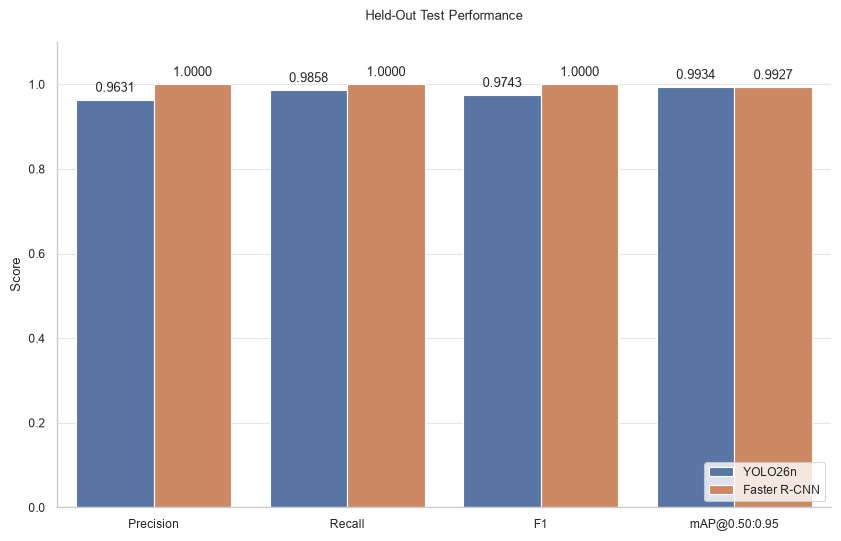

In [6]:
# Held-out test results for both models.
test_results = pd.DataFrame(
    [
        {
            "Model": "YOLO26n",
            "Precision": 0.9631,
            "Recall": 0.9858,
            "F1": 0.9743,
            "mAP@0.50": 0.9938,
            "mAP@0.75": 0.9938,
            "mAP@0.50:0.95": 0.9934,
        },
        {
            "Model": "Faster R-CNN",
            "Precision": 1.0000,
            "Recall": 1.0000,
            "F1": 1.0000,
            "mAP@0.50": 1.0000,
            "mAP@0.75": 1.0000,
            "mAP@0.50:0.95": 0.9927,
        },
    ]
)

plot_metrics = [
    "Precision",
    "Recall",
    "F1",
    "mAP@0.50:0.95",
]

# Reshape the selected metrics for plotting.
test_plot = test_results[
    ["Model"] + plot_metrics
].melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score",
)

# Compare held-out test performance.
fig, ax = plt.subplots(figsize=(8.5, 5.5))

sns.barplot(
    data=test_plot,
    x="Metric",
    y="Score",
    hue="Model",
    ax=ax,
)

ax.set_title("Held-Out Test Performance", pad=16)
ax.set_xlabel("")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.10)
ax.legend(
    title="",
    loc="lower right",
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.4f",
        padding=4,
        fontsize=9,
    )

sns.despine()
plt.tight_layout()
plt.show()

## Test Results

In [7]:
test_results.round(4)


,Model,Precision,Recall,F1,mAP@0.50,mAP@0.75,mAP@0.50:0.95
0,YOLO26n,0.9631,0.9858,0.9743,0.9938,0.9938,0.9934
1,Faster R-CNN,1.0000,1.0000,1.0000,1.0000,1.0000,0.9927


## Training Summary

In [8]:
# Find the best validation epoch for each model.
best_validation = (
    validation.loc[
        validation.groupby("Model")[
            "mAP@0.50:0.95"
        ].idxmax(),
        [
            "Model",
            "Epoch",
            "mAP@0.50:0.95",
        ],
    ]
    .rename(
        columns={
            "Epoch": "Best Epoch",
            "mAP@0.50:0.95":
                "Best Validation mAP@0.50:0.95",
        }
    )
    .sort_values("Model")
    .reset_index(drop=True)
)

best_validation["Final Epoch"] = (
    best_validation["Model"].map({
        "YOLO26n": int(yolo_epoch.max()),
        "Faster R-CNN": int(frcnn["epoch"].max()),
    })
)

best_validation[
    [
        "Model",
        "Best Epoch",
        "Final Epoch",
        "Best Validation mAP@0.50:0.95",
    ]
].round(4)

,Model,Best Epoch,Final Epoch,Best Validation mAP@0.50:0.95
0,Faster R-CNN,25,30,0.9886
1,YOLO26n,64,84,0.9934
